# Formula One Pit Stop Prediction

## Data Preparation

This notebook prepares the Formula One strategy dataset for the machine learning models used throughout this project.

The workflow begins by exploring the dataset, followed by cleaning the data, engineering additional features, splitting the data chronologically, and finally preprocessing the variables so they can be passed into the neural network.

# 1. Import Required Libraries

Import all of the libraries required throughout the data preparation process. These libraries are used for data manipulation, visualization, preprocessing, and ensuring reproducible results.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import tensorflow as tf

# For reproducibility
np.random.seed(1717)
tf.random.set_seed(1717)

# 2. Load the Dataset

Load the complete Formula One strategy dataset containing races from the 2022–2025 seasons.

In [2]:
df = pd.read_csv('../data/raw/f1_strategy_dataset_v6.csv')
df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0.0,0.017241,0.117647,0.0,NaN
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0.0,0.034483,0.176471,-1.0,2.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0.0,0.051724,0.235294,0.0,3.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0.0,0.068966,0.294118,0.0,4.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0.0,0.086207,0.352941,0.0,5.0


# 3. Explore the Dataset

Before building any models, it is important to understand the structure of the dataset.

This section examines the variables, checks the data types, and provides summary statistics to identify any potential issues before preprocessing begins.

In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101370 non-null  float64
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101370.000000,101371.000000,101371.000000,101371.000000,99523.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.028815,0.028815,0.432618,0.386521,-0.004636,14.355134
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.167287,0.167288,0.258129,0.259906,3.912725,10.177389
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000,1.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000,6.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000,12.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,0.000000,0.000000,0.631579,0.562500,2.000000,20.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000,77.000000


# 4. Exploratory Data Analysis

Visualize several important variables to better understand the dataset and identify potential relationships with the target variable.

These figures also help motivate several of the preprocessing and feature engineering decisions made later in the notebook.

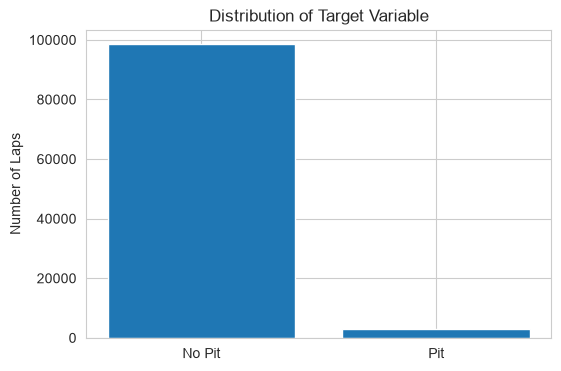

% of pit stops in the dataset: 2.88%


In [4]:
#Plotting distribution of our target variable PitNextLap
import matplotlib.pyplot as plt

pit_counts = df["PitNextLap"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(["No Pit","Pit"], pit_counts)

plt.title("Distribution of Target Variable")

plt.ylabel("Number of Laps")

plt.show()

#Pit stop percentage
pit_percentage = df["PitNextLap"].mean()*100

print(f"% of pit stops in the dataset: {pit_percentage:.2f}%")

We can see that the dataset is highly imbalanced in terms of our target variable; this is expected because pit stops occur infrequently relative to the total number of racing laps. (usually 1-3 times per race). This naturally motivates our use of binary focal cross-entropy over regular b.c.e. as is justified later on!

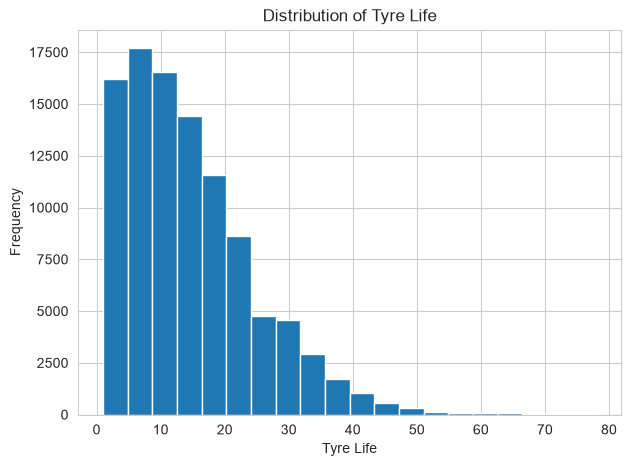

In [5]:
#Distribution of TyreLife

plt.figure(figsize=(7,5))

plt.hist(df["TyreLife"], bins=20)

plt.xlabel("Tyre Life")

plt.ylabel("Frequency")

plt.title("Distribution of Tyre Life")

plt.show()

 The distribution is right-skewed, as expected as pit stops happen more frequently as tyres age, so we are less likely to see instances of a car running on tyres for 50+ laps.

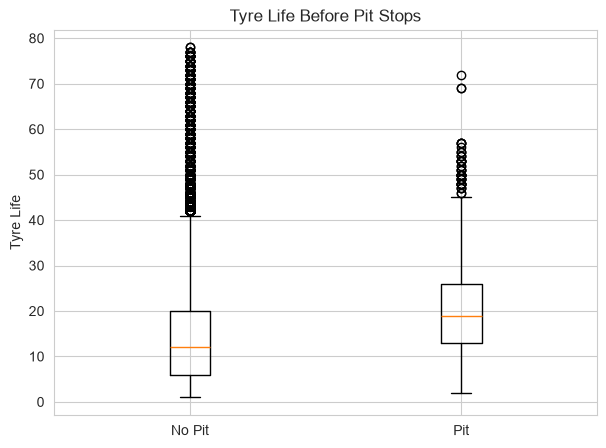

In [6]:
#TyreLife by PitNextLap

plt.figure(figsize=(7,5))

plt.boxplot(
    [
        df[df["PitNextLap"]==0]["TyreLife"],
        df[df["PitNextLap"]==1]["TyreLife"]
    ],
    tick_labels=["No Pit","Pit"]
)

plt.ylabel("Tyre Life")

plt.title("Tyre Life Before Pit Stops")

plt.show()

We see that drivers who make the choice to 'box' next lap generally have older tyres, proving that this variable is an important predictor.

(the long string of outliers under 'No Pit' is due to the scenario of the 2024 Monaco GP -- an early red flag paired with a low-degradation, low-overtaking track led to the entire field pitting within the first 3 laps and continuing on for the entire 78-lap race!)

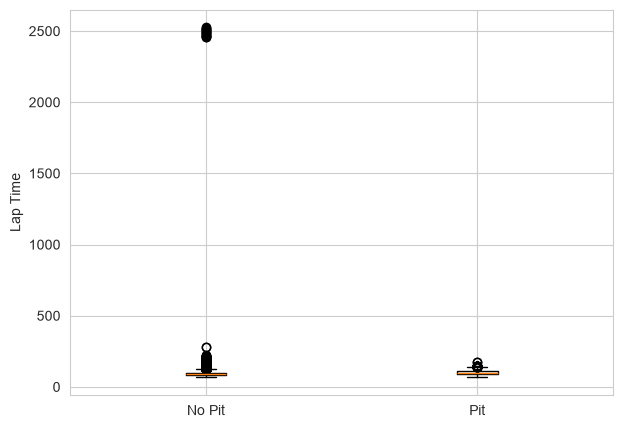

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Prev_TyreLife
43659,ALB,1,MEDIUM,1,1.0,9,2494.817,Monaco Grand Prix,2024,2403.805,2370.434,0,0.0,0.012987,0.028571,5.0,NaN
43736,ALO,1,HARD,1,2.0,13,2513.184,Monaco Grand Prix,2024,2419.536,2406.800,0,0.0,0.013158,0.057143,7.0,NaN
43812,BOT,1,HARD,1,1.0,15,2521.748,Monaco Grand Prix,2024,2429.475,2408.387,0,0.0,0.013158,0.020000,2.0,NaN


In [7]:
#Lap Time by Pit Decision
plt.figure(figsize=(7,5))

plt.boxplot(
[
df[df["PitNextLap"]==0]["LapTime (s)"],
df[df["PitNextLap"]==1]["LapTime (s)"]
],
tick_labels=["No Pit","Pit"]
)

plt.ylabel("Lap Time")

plt.show()

#Investigate unusual laptimes
high_laptimes = df.loc[df['LapTime (s)'] > 500]
high_laptimes.head(3)

Monaco 2024 seems to be causing all sorts of havoc to data analysis... this is a massive statistical outlier, but we will actually KEEP this in the dataset.

Why? Retaining Monaco 2024 exposes the neural network to critical edge cases where extreme track position and a heavily managed pace extend tire life far beyond typical degradation limits. Instead of introducing noise, keeping this race forces the network to look past simple tire age and learn the complex multi-variable trade-offs between track position and pit strategy!

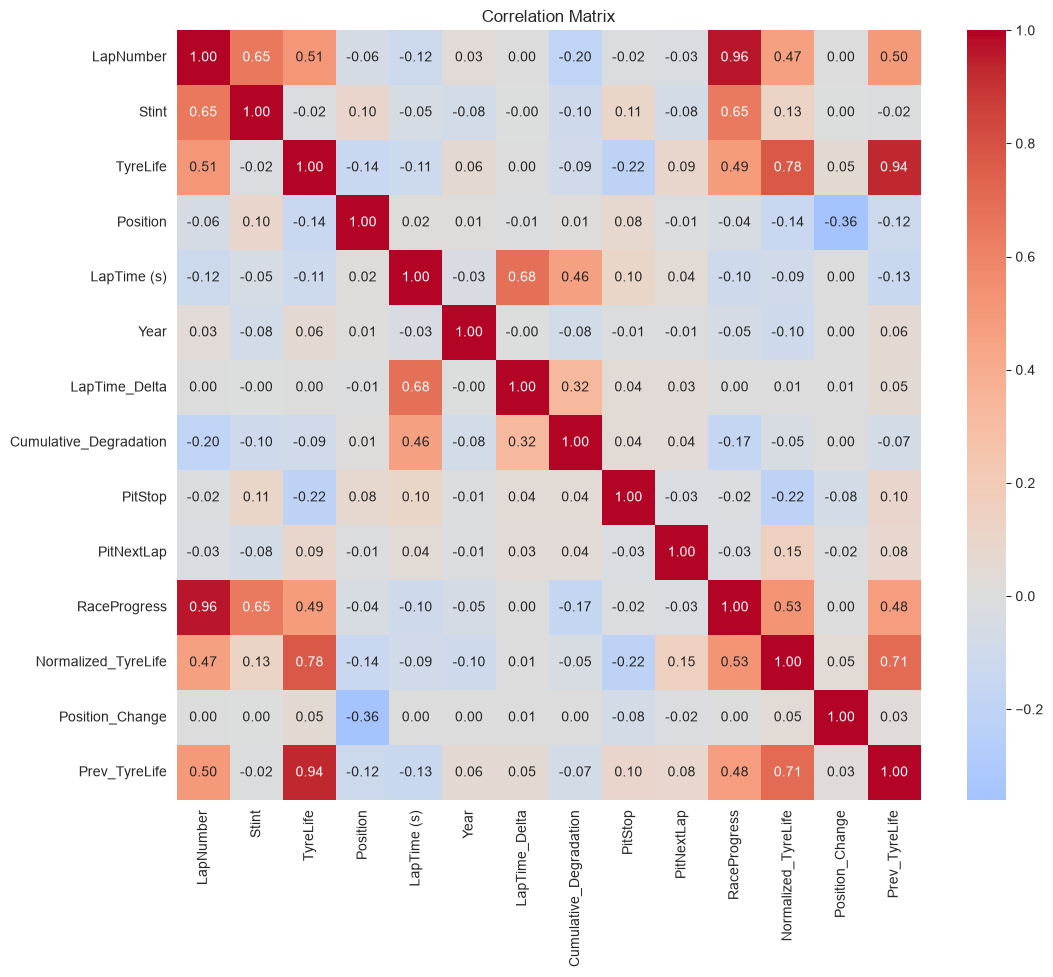

In [8]:
#Correlation Heatmap

import seaborn as sns

numeric = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

This brings up an interesting variable -- NormalizedTyreLife. It doesn't make sense for the model to use this as we WANT it to look at the real number of laps ran on a tyre compound rather than a percentage of the stint. This will only remove race bias and the model will fail to recognize how stint lengths can vary dramatically between tracks like Spa as compared to Monaco.

# 5. Clean the Dataset

Prepare the dataset for modelling by removing unnecessary variables and handling missing values.

The objective of this section is to ensure that the dataset is complete and ready for feature engineering.

In [9]:
#Drop NormalizedTyreLife, Position_Change and PitStop
df = df.drop(columns=[
    "Normalized_TyreLife",
    "PitStop"
])

Dropping the PitStop variable removes redundancy and data leakage -- we already get the same information from PitNextLap, so this would only serve to let our model cheat and learn improperly.

In [10]:
#check for any missing data
df.isnull().sum()

Driver                       0
LapNumber                    0
Compound                    66
Stint                        0
TyreLife                     0
Position                     0
LapTime (s)                  0
Race                         0
Year                         0
LapTime_Delta                0
Cumulative_Degradation       0
PitNextLap                   1
RaceProgress                 0
Position_Change              0
Prev_TyreLife             1848
dtype: int64

So now it looks like there's missing tyre compounds and something with PitNextLap... let's investigate.

In [11]:
missing_compound = df[df['Compound'].isnull()]
missing_compound.head(20)

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitNextLap,RaceProgress,Position_Change,Prev_TyreLife
81155,RUS,41,NaN,3,4.0,14,88.280,Austrian Grand Prix,2022,-18.953,-89.270,0.0,0.569444,-11.0,29.0
81156,RUS,42,NaN,3,5.0,11,70.358,Austrian Grand Prix,2022,-36.819,-95.729,0.0,0.583333,-8.0,4.0
81157,RUS,43,NaN,3,6.0,11,70.406,Austrian Grand Prix,2022,-37.166,-95.681,0.0,0.597222,-8.0,5.0
81158,RUS,44,NaN,3,7.0,8,70.936,Austrian Grand Prix,2022,-36.915,-95.151,0.0,0.611111,-5.0,6.0
81159,RUS,45,NaN,3,8.0,7,70.296,Austrian Grand Prix,2022,-37.442,-95.791,0.0,0.625000,-4.0,7.0
81160,RUS,46,NaN,3,9.0,7,70.652,Austrian Grand Prix,2022,-9.927,-95.435,0.0,0.638889,-3.0,8.0
81161,RUS,47,NaN,3,10.0,7,70.192,Austrian Grand Prix,2022,-7.092,-95.895,0.0,0.652778,-3.0,9.0
81162,RUS,48,NaN,3,11.0,7,70.454,Austrian Grand Prix,2022,-6.602,-95.633,0.0,0.666667,-3.0,10.0
81163,RUS,49,NaN,3,12.0,7,69.959,Austrian Grand Prix,2022,-26.765,-114.201,0.0,0.680556,-3.0,11.0
81164,RUS,50,NaN,3,13.0,7,70.066,Austrian Grand Prix,2022,-39.081,-114.094,0.0,0.694444,-3.0,12.0


 Looks like there's improper data for Russell's 2nd stint in Austria 2022 and Stroll's 2nd stint in Monaco 2022... let's add those in manually.

In [12]:
# Fill missing tyre compounds manually

df.loc[
    (df["Driver"] == "RUS") &
    (df["Race"] == "Austrian Grand Prix") &
    (df["Year"] == 2022) &
    (df["Stint"] == 3),
    "Compound"
] = "SOFT"


df.loc[
    (df["Driver"] == "STR") &
    (df["Race"] == "Monaco Grand Prix") &
    (df["Year"] == 2022) &
    (df["Stint"] == 5),
    "Compound"
] = "HARD"

In [13]:
#Check and remove any duplicate rows related to compounds
df[df["Compound"].isna()][["Driver","Race","Year","Stint"]].drop_duplicates()

,Driver,Race,Year,Stint


Now let's investigate the PitNextLap anomaly.

In [14]:
#examine the row with missing PitNextLap
df[df['PitNextLap'].isnull()]

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitNextLap,RaceProgress,Position_Change,Prev_TyreLife
101370,ZHO,56,HARD,3,33.0,14,103.881,United States Grand Prix,2022,21.39,-89.756,NaN,0.777778,4.0,32.0


This is the last lap of the 2022 USGP so we will manually set that value to 0.0.

Let's also fix the issues with Prev_TyreLife by setting any NaN values to 0 (any tyres on the 1st stint never had a previous tyre life)

In [15]:
#manually filling in the data for PitNextLap and Prev_TyreLife
df.loc[df.index[-1], 'PitNextLap'] = 0.0
df["Prev_TyreLife"] = df["Prev_TyreLife"].fillna(0)

In [16]:
#Now we should be OK
df.isnull().sum()

Driver                    0
LapNumber                 0
Compound                  0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
Race                      0
Year                      0
LapTime_Delta             0
Cumulative_Degradation    0
PitNextLap                0
RaceProgress              0
Position_Change           0
Prev_TyreLife             0
dtype: int64

# 6. Feature Engineering

Create several additional features that may help the model better capture the factors that influence pit-stop decisions.

These features aim to describe tyre degradation, recent pace, and race progression more effectively than the original variables alone.

In [17]:
#Tyre wear relative to race progress
df["TyreWearRate"] = df["TyreLife"] / (df["RaceProgress"] + 0.01)

# Squared tyre age
df["TyreLifeSquared"] = df["TyreLife"] ** 2

In [18]:
# Sort chronologically within each driver and race to prepare for adding rolling features

df = df.sort_values(
    by=["Year", "Race", "Driver", "LapNumber"]
)

In [19]:
#Create ROLLING FEATURES!!

# Rolling average of lap time over previous 3 laps
df["RollingLapTime3"] = (
    df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Rolling average over previous 5 laps
df["RollingLapTime5"] = (
    df.groupby(["Year", "Race", "Driver"])["LapTime (s)"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

#Rolling lap delta
df["RollingDelta3"] = (
    df.groupby(["Year","Race","Driver"])["LapTime_Delta"]
      .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

df["RollingDelta5"] = (
    df.groupby(["Year","Race","Driver"])["LapTime_Delta"]
      .transform(lambda x: x.rolling(5, min_periods=1).mean())
)

#Rolling lap time variance
df["RollingLapStd3"] = (

    df.groupby(["Year","Race","Driver"])["LapTime (s)"].transform(lambda x:x.rolling(3,min_periods=2).std())

)

df["RollingLapStd3"] = df["RollingLapStd3"].fillna(0)

#----------------------------------------------------#

df["RollingLapStd5"] = (

    df.groupby(["Year","Race","Driver"])["LapTime (s)"].transform(lambda x:x.rolling(5,min_periods=2).std())

)

df["RollingLapStd5"] = df["RollingLapStd5"].fillna(0)

In [20]:
#Previous Lap Time
df["PreviousLapTime"] = (
    df.groupby(["Year","Race","Driver"])["LapTime (s)"]
      .shift(1)
)

df["PreviousLapTime"] = df["PreviousLapTime"].fillna(df["LapTime (s)"])

#Lap Time Increase
df["LapTimeIncrease"] = (
    df["LapTime (s)"] -
    df["PreviousLapTime"]
)

# Remaining race
df["RemainingRace"] = 1 - df["RaceProgress"]

# 7. Split the Dataset

Split the dataset chronologically into training, validation, and testing sets.

Using complete seasons rather than a random split prevents temporal data leakage and provides a more realistic evaluation of how the model would perform on future races.

In [21]:
#Split data into training, validation, and testing data using a CHRONOLOGICAL SPLIT

#We will train the neural network using data from the 2022–2024 Formula One seasons and evaluate it on the unseen 2025 season!

train_df = df[df["Year"].isin([2022, 2023])]

val_df = df[df["Year"] == 2024]

test_df = df[df["Year"] == 2025]

In [22]:
#Verify split sizes

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(46774, 26)
(27557, 26)
(27040, 26)


## Separate Inputs and Outputs

Separate the predictor variables from the target variable (PitNextLap) for each subset of the data.

In [23]:
#Establish inputs and outputs of the neural network

X_train = train_df.drop("PitNextLap", axis=1)
y_train = train_df["PitNextLap"]

X_val = val_df.drop("PitNextLap", axis=1)
y_val = val_df["PitNextLap"]

X_test = test_df.drop("PitNextLap", axis=1)
y_test = test_df["PitNextLap"]

## Identify Feature Types

Separate the predictor variables into numerical and categorical features so that the appropriate preprocessing methods can be applied to each group.

In [24]:
#Identify feature types

categorical_features = [
    "Driver",
    "Compound",
    "Race"
]

numerical_features = [

    "LapNumber",
    "Stint",
    "TyreLife",
    "TyreLifeSquared",
    "TyreWearRate",

    "Position",

    "LapTime (s)",
    "LapTime_Delta",
    "PreviousLapTime",
    "LapTimeIncrease",

    "RollingLapTime3",
    "RollingLapTime5",
    "RollingDelta3",
    "RollingDelta5",

    "Cumulative_Degradation",

    "RaceProgress",
    "RemainingRace",
    "Position_Change",
    "Prev_TyreLife",
    "RollingLapStd3",
    "RollingLapStd5"

]

# 10. Build the Preprocessing Pipeline

Construct the preprocessing pipeline used throughout the project.

Numerical features are standardized while categorical variables are converted using one-hot encoding. The pipeline is fitted only on the training data before being applied to the validation and testing datasets.

In [25]:
#Build preprocessing pipeline! (one-hot encoding and standard scaling)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

#preventing errors from changes to F1 driver lineups
handle_unknown="ignore"

In [26]:
#Fitting on training data

X_train = preprocessor.fit_transform(X_train)

X_val = preprocessor.transform(X_val)

X_test = preprocessor.transform(X_test)

# 11. Save the Processed Data

Save the processed datasets and preprocessing pipeline so they can be reused during model training.

Separating the data preparation stage from model training ensures that the same processed datasets are used consistently throughout the remainder of the project.

In [27]:
import joblib

#Save preprocessor
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

#Save processed arrays
np.save("../data/processed/X_train.npy", X_train)
np.save("../data/processed/X_val.npy", X_val)
np.save("../data/processed/X_test.npy", X_test)

np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_val.npy", y_val.values)
np.save("../data/processed/y_test.npy", y_test.values)

#Save datasets
joblib.dump(train_df, "../data/processed/train_df.pkl")
joblib.dump(val_df, "../data/processed/val_df.pkl")
joblib.dump(test_df, "../data/processed/test_df.pkl")

# Save original dataframe for plotting
test_df.to_csv(
    "../data/processed/test_df.csv",
    index=False
)

#Save features for group ablation
joblib.dump(
    numerical_features,
    "../data/processed/numerical_features.pkl"
)

joblib.dump(
    categorical_features,
    "../data/processed/categorical_features.pkl"
)

print("Data preparation complete.")

Data preparation complete.
